<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/Geopandas_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import geopandas as gpd

In [2]:
import os

In [3]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
  os.makedirs(data_folder)

if not os.path.exists(output_folder):
  os.makedirs(output_folder)

In [4]:
import requests

In [5]:
def download(url):

  filename = os.path.join(data_folder, os.path.basename(url))

  if not os.path.exists(filename):
    response = requests.get(url, allow_redirects=True)
    with open(filename, 'wb') as f:
      f.write(response.content)
    print(f'Downloaded {filename}')


In [6]:
file_url = 'https://raw.githubusercontent.com/Calotriton/Learning_GIS/main/GIS_vector/data/Austin/austin_pop_density_2019.gpkg'
download(file_url)

Downloaded data/austin_pop_density_2019.gpkg


In [7]:
data_path = os.path.join(data_folder, 'austin_pop_density_2019.gpkg')
data = gpd.read_file(data_path)
data.head()

,pop2019,tract,area_km2,pop_density_km2,geometry
0,6070.0,002422,4029.771797,1.506289,"POLYGON ((615643.487 3338728.496, 615645.477 3..."
1,2203.0,001751,1532.029989,1.437961,"POLYGON ((618576.586 3359381.053, 618614.33 33..."
2,7419.0,002411,3960.343857,1.873322,"POLYGON ((619200.163 3341784.654, 619270.849 3..."
3,4229.0,000401,2181.761674,1.938342,"POLYGON ((621623.757 3350508.165, 621656.294 3..."
4,4589.0,002313,2431.208488,1.887539,"POLYGON ((621630.247 3345130.744, 621717.926 3..."


In [8]:
data['area_km2'] = data.area/1000000
data.head()

,pop2019,tract,area_km2,pop_density_km2,geometry
0,6070.0,002422,4.029772,1.506289,"POLYGON ((615643.487 3338728.496, 615645.477 3..."
1,2203.0,001751,1.532030,1.437961,"POLYGON ((618576.586 3359381.053, 618614.33 33..."
2,7419.0,002411,3.960344,1.873322,"POLYGON ((619200.163 3341784.654, 619270.849 3..."
3,4229.0,000401,2.181762,1.938342,"POLYGON ((621623.757 3350508.165, 621656.294 3..."
4,4589.0,002313,2.431208,1.887539,"POLYGON ((621630.247 3345130.744, 621717.926 3..."


<Axes: >

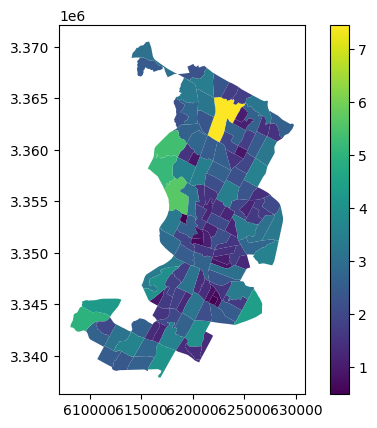

In [11]:
data.plot(column='area_km2', legend=True)

In [12]:
data["pop_density_km2"] = data["pop2019"] / data["area_km2"]
data.head()

,pop2019,tract,area_km2,pop_density_km2,geometry
0,6070.0,002422,4.029772,1506.288769,"POLYGON ((615643.487 3338728.496, 615645.477 3..."
1,2203.0,001751,1.532030,1437.961408,"POLYGON ((618576.586 3359381.053, 618614.33 33..."
2,7419.0,002411,3.960344,1873.322183,"POLYGON ((619200.163 3341784.654, 619270.849 3..."
3,4229.0,000401,2.181762,1938.341868,"POLYGON ((621623.757 3350508.165, 621656.294 3..."
4,4589.0,002313,2.431208,1887.538655,"POLYGON ((621630.247 3345130.744, 621717.926 3..."


In [13]:
data.crs

<Projected CRS: EPSG:32614>
Name: WGS 84 / UTM zone 14N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 102°W and 96°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Manitoba; Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-102.0, 0.0, -96.0, 84.0)
Coordinate Operation:
- name: UTM zone 14N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [14]:
import matplotlib.pyplot as plt

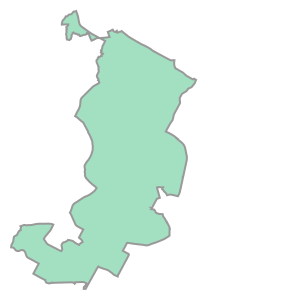

In [15]:
data.union_all()

The .union_all() method returns a shapely polygon object out of the results. It is also possible to merge geometries using a method called .dissolve() that returns a GeoDataFrame as an output (with aggregated attribute information). Both the .union_all() and the .dissolve() support two different kind of algorithms to form the merged geometry: "unary" (the default) and "coverage" which is optimized for non-overlapping polygons and can be significantly faster to compute. As our data here, does not have any overlapping polygons, we can test how merging the geometries work with the "coverage" algorithm:

In [16]:
dissolved = data.dissolve(method='coverage')
dissolved.head()

,geometry,pop2019,tract,area_km2,pop_density_km2
0,"MULTIPOLYGON (((618353.957 3340531.111, 618350...",6070.0,002422,4.029772,1506.288769


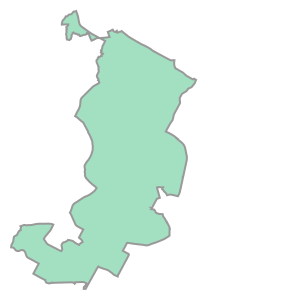

In [18]:
dissolved.geometry[0]

As a result, the dissolved variable now contains the merged geometry as well as the attribute information associated with it. When looking at the returned geometry, we can see that it is identical to the one returned by .union_all() method. Notice that by default the .dissolve() simply stores the first row of data as an attribute information. It is, however, possible to control how the attribute information should be aggregated/summarized, e.g. by summing the values. Read more information about this later from the section where we introduce more thoroughly the functionality of .dissolve().

## bounding polygon

<Axes: >

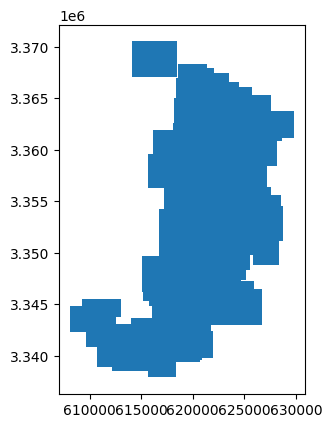

In [19]:
evelope = data.envelope
evelope.plot()

In order to get the bounding rectangle for the whole layer, we first create an union of all geometries using the .union_all() method, and then extract the bounding rectangle for that polygon using the .envelope:

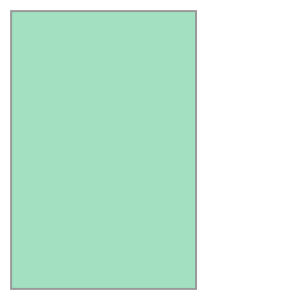

In [22]:
data.union_all().envelope

Corner coordinates of the bounding box for a GeoDataFrame can be fetched via the total_bounds attribute:

In [23]:
data.total_bounds

array([ 608125.39434001, 3337909.89495403,  629828.38846075,
       3370513.6825782 ])

The bounds attribute returns the bounding coordinates of each feature:

In [24]:
data.bounds.head()

,minx,miny,maxx,maxy
0,615643.487492,3.337910e+06,618358.032738,3.341257e+06
1,618529.497100,3.358797e+06,620192.631882,3.360614e+06
2,619198.455980,3.340875e+06,621733.879615,3.343443e+06
3,621599.086586,3.350329e+06,623714.365506,3.352436e+06
4,621630.247042,3.343016e+06,624133.188692,3.345131e+06


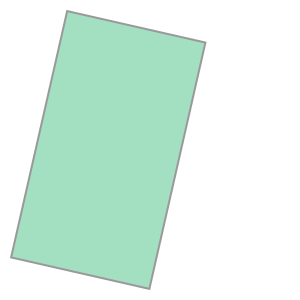

In [26]:
data.dissolve().minimum_rotated_rectangle().geometry[0]

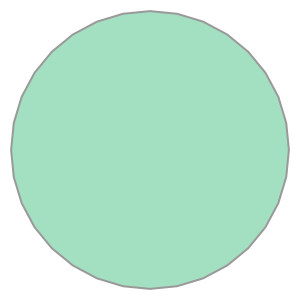

In [27]:
data.dissolve().minimum_bounding_circle().geometry[0]

A bit more detailed delineation of the data extent can be extracted using a convex hull which represents the smalles possible polygon that contains all points in an object.

In [28]:
data.convex_hull.head()

,0
0,"POLYGON ((616870.883 3337909.895, 616852.964 3..."
1,"POLYGON ((619496.705 3358797, 618962.703 33590..."
2,"POLYGON ((619848.5 3340875.421, 619811.394 334..."
3,"POLYGON ((622145.426 3350329.32, 622132.429 33..."
4,"POLYGON ((623931.77 3343015.679, 622426.307 33..."


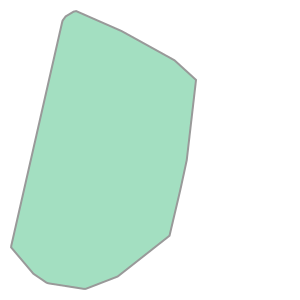

In [29]:
data.union_all().convex_hull

Concave hull

A concave hull is a polygon that encloses a set of points but, unlike the convex hull, is allowed to have concavities. In simpler terms, while a convex hull wraps around the outermost points in the tightest convex manner (like a stretched rubber band), a concave hull can bend inward to more closely follow the distribution of the points, providing a boundary that might be more representative of the actual shape of the dataset.

In [31]:
data.concave_hull().head()

,0
0,"POLYGON ((616686.447 3341251.083, 616689.559 3..."
1,"POLYGON ((619414.904 3360602.695, 619418.528 3..."
2,"POLYGON ((620165.029 3343417.634, 620177.845 3..."
3,"POLYGON ((622361 3352408.88, 622364.565 335241..."
4,"POLYGON ((621654.405 3344983.596, 621630.247 3..."


<Axes: >

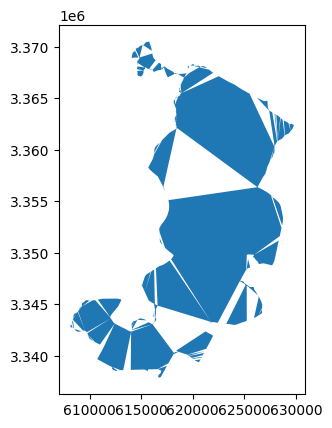

In [33]:
data.dissolve().concave_hull().plot()